# 03 -- Бейслайны

Начинаю с популярности и пересечения слов. Затем проверяю TF-IDF, BM25, историю запросов
и Naive Bayes по типу услуги. В конце объединяю выдачи через RRF.
Так видно, что дает каждый источник до обучения более сложной модели.

In [1]:
from collections import defaultdict

from pathlib import Path

import json

import time

import numpy as np

import pandas as pd

from scipy import sparse

from sklearn.feature_extraction.text import (
    CountVectorizer,
    TfidfTransformer,
    TfidfVectorizer,
)

from sklearn.naive_bayes import MultinomialNB


In [2]:
def top_indices(scores, k=100, allowed=None):
    scores = np.asarray(scores).ravel()
    positions = np.arange(len(scores)) if allowed is None else np.asarray(allowed)
    if not len(positions):
        return np.empty(0, dtype=np.int32)
    values = scores[positions]
    valid = np.isfinite(values) & (values > 0)
    positions, values = positions[valid], values[valid]
    if len(positions) > k:
        # Все ties на границе проходят во второй этап: результат не зависит от argpartition.
        threshold = np.partition(values, -k)[-k]
        keep = values >= threshold
        positions, values = positions[keep], values[keep]
    order = np.lexsort((positions, -values))[:k]
    return positions[order].astype(np.int32)


In [3]:
def sparse_top(row, k=100, allowed_mask=None):
    row = row.tocsr()
    idx, values = row.indices, row.data
    keep = values > 0
    if allowed_mask is not None:
        keep &= allowed_mask[idx]
    idx, values = idx[keep], values[keep]
    if len(idx) > k:
        threshold = np.partition(values, -k)[-k]
        keep = values >= threshold
        idx, values = idx[keep], values[keep]
    order = np.lexsort((idx, -values))[:k]
    return idx[order], values[order]


In [4]:
class LexicalIndex:
    def __init__(self):
        self.word = CountVectorizer(
            min_df=2, max_features=160000, ngram_range=(1, 2), dtype=np.float32
        )
        self.title = CountVectorizer(
            min_df=2, max_features=100000, ngram_range=(1, 1), dtype=np.float32
        )
        self.char = TfidfVectorizer(
            analyzer='char_wb',
            ngram_range=(3, 5),
            min_df=3,
            max_features=180000,
            sublinear_tf=True,
            dtype=np.float32,
        )

    @staticmethod
    def bm25_matrix(counts, k1=1.2, b=0.75):
        lengths = np.asarray(counts.sum(axis=1)).ravel()
        df = np.asarray((counts > 0).sum(axis=0)).ravel()
        idf = np.log1p((counts.shape[0] - df + 0.5) / (df + 0.5))
        result = counts.copy().tocsr()
        norm = k1 * (1 - b + b * lengths / max(float(lengths.mean()), 1))
        result.data = (
            result.data
            * (k1 + 1)
            / (result.data + np.repeat(norm, np.diff(result.indptr)))
        )
        return result.multiply(idf.astype(np.float32)).tocsr()

    def fit(self, items):
        counts = self.word.fit_transform(items.lexical_text).tocsr()
        self.tfidf = TfidfTransformer(sublinear_tf=True)
        self.word_matrix = self.tfidf.fit_transform(counts).astype(np.float32)
        self.bm25 = self.bm25_matrix(counts)
        del counts
        title_counts = self.title.fit_transform(items.title_text).tocsr()
        self.overlap = title_counts.copy()
        self.overlap.data[:] = 1
        self.title_bm25 = self.bm25_matrix(title_counts)
        self.char_matrix = self.char.fit_transform(items.title_text).tocsr()
        return self

    def search(self, queries, items, k=120, methods=None, progress=True):
        methods = methods or ['overlap', 'word', 'char', 'bm25', 'bm25_title']
        qword = self.word.transform(queries.query_text)
        qtitle = self.title.transform(queries.text_key)
        qtitle.data[:] = 1
        qword_binary = qword.copy()
        qword_binary.data[:] = 1
        pairs = {
            'overlap': (qtitle, self.overlap),
            'word': (self.tfidf.transform(qword), self.word_matrix),
            'char': (self.char.transform(queries.text_key), self.char_matrix),
            'bm25': (qword_binary, self.bm25),
            'bm25_title': (qtitle, self.title_bm25),
        }
        locations = items.item_location_id.to_numpy()
        rows = []
        for method in methods:
            qm, im = pairs[method]
            start = time.monotonic()
            for batch in range(0, len(queries), 32):
                scores = (qm[batch : batch + 32] @ im.T).tocsr()
                for offset in range(scores.shape[0]):
                    q = queries.iloc[batch + offset]
                    row = scores.getrow(offset)
                    for suffix, mask in [
                        ('', None),
                        ('_local', locations == q.search_location_id),
                    ]:
                        pos, values = sparse_top(row, k, mask)
                        rows.extend(
                            (q.query_id, int(p), method + suffix, rank + 1, float(s))
                            for rank, (p, s) in enumerate(zip(pos, values))
                        )
            if progress:
                print(
                    f'{method}: {len(queries)} queries, {time.monotonic()-start:.1f}s',
                    flush=True,
                )
        return compact_candidates(
            pd.DataFrame(rows, columns=['query_id', 'pos', 'source', 'rank', 'score'])
        )


In [5]:
class HistoryIndex:
    def fit(self, pairs, items, label_catalog=None):
        self.items = items[
            ['item_id', 'item_location_id', 'item_category_id', 'item_microcat_id']
        ].copy()
        self.position = dict(zip(items.item_id, items.index))
        self.pop = pairs.item_id.value_counts().to_dict()
        counts = np.array([self.pop.get(i, 0) for i in items.item_id], dtype=np.float32)
        self.pop_scores = counts
        self.context = self._hist(pairs, 'context_key')
        self.text = self._hist(pairs, 'text_key')
        unique = (
            pairs[pairs.text_key.isin(self.text)]
            .drop_duplicates('text_key')
            .sort_values('text_key')
        )
        self.hist_texts = unique.text_key.tolist()
        self.query_vectorizer = TfidfVectorizer(
            analyzer='char_wb',
            ngram_range=(3, 5),
            min_df=1,
            max_features=100000,
            dtype=np.float32,
        )
        self.query_matrix = self.query_vectorizer.fit_transform(self.hist_texts)
        meta = (
            (items if label_catalog is None else label_catalog)
            .set_index('item_id')
            .item_microcat_id
        )
        train = pairs[pairs.item_id.isin(meta.index)].copy()
        # Naive Bayes предсказывает тип услуги, а не 500 тысяч классов item_id.
        self.nb_vectorizer = TfidfVectorizer(
            ngram_range=(1, 2), min_df=2, max_features=80000, dtype=np.float32
        )
        x = self.nb_vectorizer.fit_transform(train.query_text)
        self.nb = MultinomialNB(alpha=0.2).fit(x, train.item_id.map(meta).astype(str))
        self.microcat_positions = {
            str(cat): np.asarray(idx, dtype=np.int32)
            for cat, idx in items.groupby('item_microcat_id').groups.items()
        }
        return self

    def _hist(self, pairs, key):
        counts = pairs.groupby([key, 'item_id']).size().rename('count').reset_index()
        out = defaultdict(list)
        for row in counts.itertuples(index=False):
            p = self.position.get(row.item_id)
            if p is not None:
                out[getattr(row, key)].append((p, float(row.count)))
        return {
            key: sorted(values, key=lambda x: (-x[1], x[0]))
            for key, values in out.items()
        }

    def search(self, queries, k=120):
        rows = []
        locations = self.items.item_location_id.to_numpy()
        categories = self.items.item_category_id.to_numpy()
        near = (
            self.query_vectorizer.transform(queries.text_key) @ self.query_matrix.T
        ).tocsr()
        nb_probs = self.nb.predict_proba(
            self.nb_vectorizer.transform(queries.query_text)
        )
        for j, q in enumerate(queries.itertuples(index=False)):
            local = np.flatnonzero(locations == q.search_location_id)
            category = np.flatnonzero(categories == q.search_category)
            channels = {
                'popularity': [
                    (int(p), self.pop_scores[p])
                    for p in top_indices(self.pop_scores, k)
                ],
                'popularity_local': [
                    (int(p), self.pop_scores[p])
                    for p in top_indices(self.pop_scores, k, local)
                ],
                'popularity_category': [
                    (int(p), self.pop_scores[p])
                    for p in top_indices(self.pop_scores, k, category)
                ],
                'history': self.text.get(q.text_key, [])[:k],
                'history_context': self.context.get(q.context_key, [])[:k],
                'history_local': [
                    (p, s)
                    for p, s in self.text.get(q.text_key, [])
                    if locations[p] == q.search_location_id
                ][:k],
            }
            npos, nsim = sparse_top(near.getrow(j), 8)
            similar = defaultdict(float)
            for p, s in zip(npos, nsim):
                # Exact history -- отдельный канал; не удваиваю ее этим источником.
                if self.hist_texts[p] == q.text_key or s < 0.2:
                    continue
                for item, count in self.text.get(self.hist_texts[p], [])[:200]:
                    similar[item] += float(s) ** 3 * np.log1p(count)
            channels['similar_history'] = sorted(
                similar.items(), key=lambda x: (-x[1], x[0])
            )[:k]
            channels['similar_history_local'] = sorted(
                (
                    (p, s)
                    for p, s in similar.items()
                    if locations[p] == q.search_location_id
                ),
                key=lambda x: (-x[1], x[0]),
            )[:k]
            cats = np.argsort(-nb_probs[j])[:3]
            nb_scores = {}
            for catpos in cats:
                pos = self.microcat_positions.get(
                    str(self.nb.classes_[catpos]), np.array([], dtype=int)
                )
                for p in top_indices(self.pop_scores + 1, k, pos):
                    nb_scores[int(p)] = float(nb_probs[j, catpos]) * float(
                        np.log1p(self.pop_scores[p]) + 1
                    )
            channels['naive_bayes'] = sorted(
                nb_scores.items(), key=lambda x: (-x[1], x[0])
            )[:k]
            channels['naive_bayes_local'] = []
            for catpos in cats:
                pos = self.microcat_positions.get(
                    str(self.nb.classes_[catpos]), np.array([], dtype=int)
                )
                pos = pos[locations[pos] == q.search_location_id]
                for p in top_indices(self.pop_scores + 1, k, pos):
                    channels['naive_bayes_local'].append(
                        (
                            int(p),
                            float(nb_probs[j, catpos])
                            * (np.log1p(self.pop_scores[p]) + 1),
                        )
                    )
            channels['naive_bayes_local'].sort(key=lambda x: (-x[1], x[0]))
            for source, values in channels.items():
                rows.extend(
                    (q.query_id, p, source, rank + 1, float(s))
                    for rank, (p, s) in enumerate(values[:k])
                )
        return compact_candidates(
            pd.DataFrame(rows, columns=['query_id', 'pos', 'source', 'rank', 'score'])
        )


In [6]:
from pathlib import Path
import sys
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

bl_root = Path.cwd() if (Path.cwd() / 'notebooks').exists() else Path.cwd().parent
import nbformat

# Подключаю только ячейки с функциями; расчеты других ноутбуков не запускаю.
for bl_file in ['02_feature_engineering.ipynb']:
    for bl_cell in nbformat.read(bl_root / 'notebooks' / bl_file, as_version=4).cells:
        if 'definitions' in bl_cell.metadata.get('tags', []):
            exec(bl_cell.source, globals())
bl_out = bl_root / 'outputs'
bl_seed = 143


In [7]:
import joblib
import gc

bl_items = pd.read_parquet(bl_out / 'cache/items.parquet')
bl_queries = pd.read_parquet(bl_out / 'cache/eval_queries.parquet')
bl_base = pd.read_parquet(bl_out / 'cache/base_pairs.parquet')
bl_truth_all = json.loads((bl_out / 'cache/truth.json').read_text())
bl_dev = bl_queries[bl_queries.split.eq('dev')]
bl_truth = {q: bl_truth_all[q] for q in bl_dev.query_id}
bl_index = LexicalIndex().fit(bl_items)
joblib.dump(bl_index, bl_out / 'cache/lexical_index.joblib', compress=0)
bl_history = HistoryIndex().fit(bl_base, bl_items)
joblib.dump(bl_history, bl_out / 'cache/history_index.joblib', compress=0)
print('Корпус:', len(bl_items), 'base:', len(bl_base), 'dev:', len(bl_dev))


Корпус: 515895 base: 322191 dev: 2000


## Поиск и сохранение кандидатов

Для каждого lexical метода сохраняю global и same-location top-120. Локальный канал дополняет глобальный,
а не отсекает его. Одинаковые скоры упорядочены по стабильному item-порядку.
Словарь ограничен по частоте; отсутствие токенов дает пустой ответ, а не случайные нулевые совпадения.
В `03` это компенсирует объединение источников.

In [8]:
bl_times = []
for bl_method in ['overlap', 'word', 'char', 'bm25', 'bm25_title']:
    bl_start = time.monotonic()
    bl_candidates = bl_index.search(bl_queries, bl_items, k=120, methods=[bl_method])
    bl_candidates.to_parquet(
        bl_out / f'cache/candidates_{bl_method}.parquet', index=False
    )
    bl_times.append(
        {
            'method': bl_method,
            'queries': len(bl_queries),
            'seconds': time.monotonic() - bl_start,
            'candidate_rows': len(bl_candidates),
        }
    )
    del bl_candidates
    gc.collect()
bl_start = time.monotonic()
bl_history_parts = []
for bl_startrow in range(0, len(bl_queries), 700):
    bl_part = bl_history.search(bl_queries.iloc[bl_startrow : bl_startrow + 700], k=120)
    bl_history_parts.append(bl_part)
bl_candidates = pd.concat(bl_history_parts, ignore_index=True)
bl_candidates.to_parquet(bl_out / 'cache/candidates_history.parquet', index=False)
bl_times.append(
    {
        'method': 'history+NB+pop',
        'queries': len(bl_queries),
        'seconds': time.monotonic() - bl_start,
        'candidate_rows': len(bl_candidates),
    }
)


overlap: 8400 queries, 6.3s


word: 8400 queries, 159.4s


char: 8400 queries, 60.4s


bm25: 8400 queries, 145.7s


bm25_title: 8400 queries, 6.3s


In [9]:
pd.DataFrame(bl_times).to_csv(bl_out / 'validation/retrieval_timings.csv', index=False)
del bl_candidates, bl_history_parts
gc.collect()


456

In [10]:
bl_scores = []
bl_per_query = []
for bl_file in sorted((bl_out / 'cache').glob('candidates_*.parquet')):
    if bl_file.stem in ['candidates_dense', 'candidates_adapted']:
        continue
    bl_c = pd.read_parquet(bl_file)
    bl_c = bl_c[bl_c.query_id.isin(bl_dev.query_id)]
    for bl_source, bl_group in bl_c.groupby('source', observed=True):
        bl_pred = predictions_from_frame(
            bl_group.sort_values(['query_id', 'rank']), bl_items, k=100
        )
        bl_result = recall_table(bl_pred, bl_truth).merge(
            bl_dev[['query_id', 'regime']], on='query_id'
        )
        bl_result['method'] = bl_source
        bl_per_query.append(bl_result)
        for bl_regime, bl_part in bl_result.groupby('regime'):
            bl_scores.append(
                {
                    'method': bl_source,
                    'regime': bl_regime,
                    'queries': len(bl_part),
                    **bl_part.filter(like='recall@').mean().to_dict(),
                }
            )
bl_scores = pd.DataFrame(bl_scores)
bl_scores.to_csv(bl_out / 'validation/baselines_dev.csv', index=False)
pd.concat(bl_per_query).to_parquet(
    bl_out / 'validation/baselines_per_query.parquet', index=False
)


,method,regime,queries,recall@1,recall@10,recall@20,recall@50,recall@100
2,bm25_local,cold,1000,0.187667,0.453311,0.531197,0.611106,0.655972
36,word_local,cold,1000,0.158278,0.439194,0.510547,0.600664,0.645472
10,char_local,cold,1000,0.151625,0.407169,0.459347,0.531347,0.579472
18,naive_bayes_local,cold,1000,0.029367,0.200481,0.288514,0.416806,0.508556
6,bm25_title_local,cold,1000,0.134458,0.310311,0.358922,0.398922,0.427256
32,overlap_local,cold,1000,0.116375,0.278811,0.321089,0.362256,0.414089
0,bm25,cold,1000,0.021500,0.096167,0.139917,0.222083,0.289083
8,char,cold,1000,0.029292,0.091000,0.128167,0.195167,0.251500
34,word,cold,1000,0.008500,0.065333,0.113417,0.180250,0.247917
4,bm25_title,cold,1000,0.025958,0.089042,0.117500,0.170167,0.220000


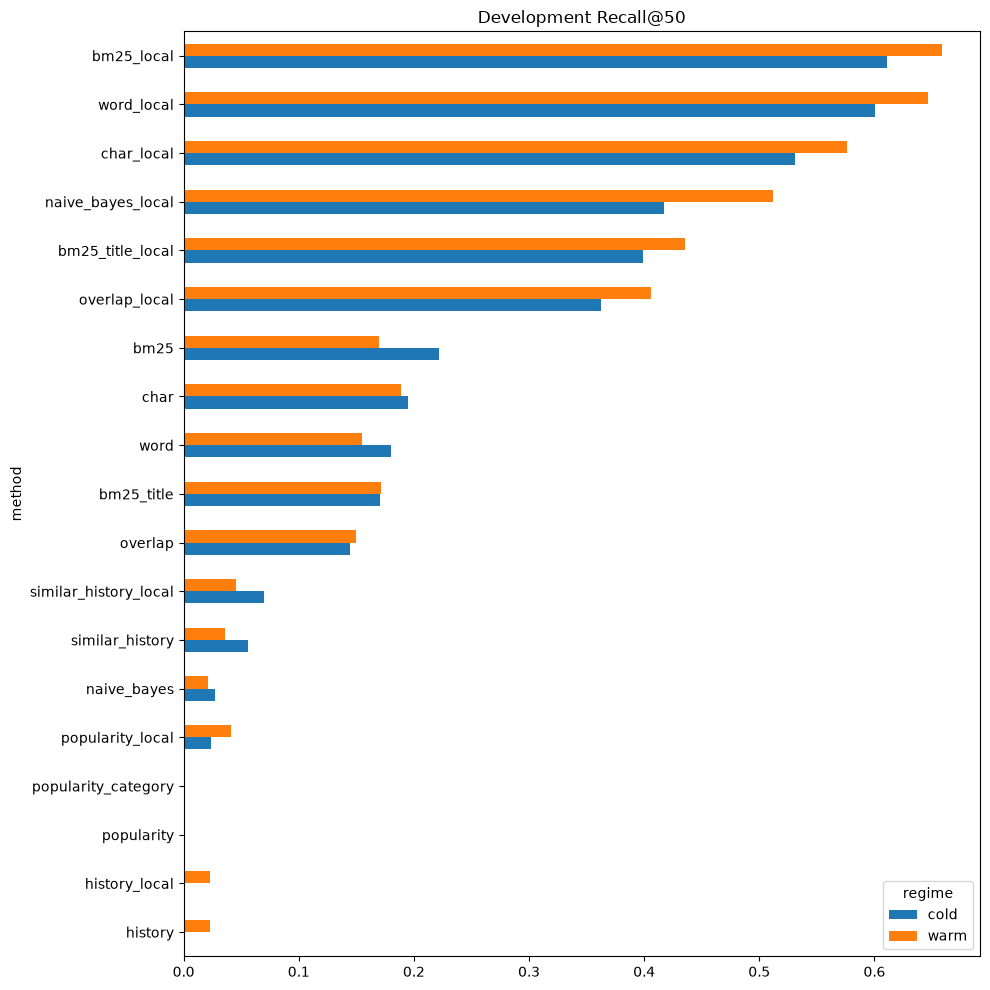

In [11]:
display(bl_scores.sort_values(['regime', 'recall@50'], ascending=[True, False]))
bl_scores.pivot(index='method', columns='regime', values='recall@50').sort_values(
    'cold'
).plot.barh(figsize=(10, 10), title='Development Recall@50')
plt.tight_layout()
plt.savefig(bl_out / 'figures/baselines.png', dpi=150)
plt.show()


## Вывод

На dev лучшие отдельные источники -- локальные BM25 и word TF-IDF. История полного контекста
не находит отложенные контексты по определению split. История текста может использовать другие
фильтры и локации. Пустые ответы оставляю в macro Recall. Следующий шаг -- проверить объединение источников.

In [12]:
bl_best = bl_scores.sort_values('recall@50', ascending=False).groupby('regime').head(1)
display(bl_best)


,method,regime,queries,recall@1,recall@10,recall@20,recall@50,recall@100
3,bm25_local,warm,1000,0.192143,0.489786,0.578690,0.658762,0.694464
2,bm25_local,cold,1000,0.187667,0.453311,0.531197,0.611106,0.655972


### Пустой источник полного контекста

`history_context` возвращает ноль кандидатов во всей локальной проверке: полные контексты целиком отложены. Его Recall@50 равен 0 и на cold, и на warm. В таблице и графике перечислены источники с хотя бы одной непустой выдачей; для каждого из них пустые запросы все равно входят в знаменатель.

## Объединение источников

Складываю обратные ранги: шкалы BM25, TF-IDF и частот разные.
Небольшую сетку весов проверяю только на dev. Пустые выдачи остаются в метрике.

In [13]:
from pathlib import Path
import sys
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

hy_root = Path.cwd() if (Path.cwd() / 'notebooks').exists() else Path.cwd().parent
import nbformat

# Подключаю только ячейки с функциями; расчеты других ноутбуков не запускаю.
for hy_file in ['02_feature_engineering.ipynb']:
    for hy_cell in nbformat.read(hy_root / 'notebooks' / hy_file, as_version=4).cells:
        if 'definitions' in hy_cell.metadata.get('tags', []):
            exec(hy_cell.source, globals())
hy_out = hy_root / 'outputs'
hy_seed = 143


In [14]:
hy_items = pd.read_parquet(hy_out / 'cache/items.parquet', columns=['item_id'])
hy_queries = pd.read_parquet(hy_out / 'cache/eval_queries.parquet')
hy_dev = hy_queries[hy_queries.split.eq('dev')]
hy_all_truth = json.loads((hy_out / 'cache/truth.json').read_text())
hy_truth = {q: hy_all_truth[q] for q in hy_dev.query_id}
hy_candidates = pd.concat(
    [
        pd.read_parquet(hy_out / f'cache/candidates_{s}.parquet')
        for s in ['word', 'char', 'bm25', 'bm25_title', 'history']
    ],
    ignore_index=True,
)
hy_candidates = hy_candidates[hy_candidates.query_id.isin(hy_dev.query_id)]
hy_sources = [
    'word',
    'word_local',
    'char',
    'char_local',
    'bm25',
    'bm25_local',
    'bm25_title',
    'bm25_title_local',
    'history',
    'history_local',
    'history_context',
    'similar_history',
    'similar_history_local',
    'naive_bayes_local',
    'popularity_local',
]


In [15]:
hy_candidates = hy_candidates[hy_candidates.source.isin(hy_sources)]
hy_union = predictions_from_frame(hy_candidates, hy_items, k=100000)
hy_ceiling = recall_table(hy_union, hy_truth, ks=(100000,)).rename(
    columns={'recall@100000': 'union_recall'}
)
display(
    hy_ceiling.merge(hy_dev[['query_id', 'regime']], on='query_id')
    .groupby('regime')
    .union_recall.mean()
)
hy_ceiling.to_csv(hy_out / 'validation/union_ceiling_dev.csv', index=False)


regime
cold    0.868306
warm    0.877714
Name: union_recall, dtype: float64

In [16]:
hy_trials = []
hy_configs = []
for hy_local_weight in [1.0, 2.0, 4.0]:
    for hy_history_weight in [0.5, 1.5, 3.0]:
        hy_weights = {s: 1.0 for s in hy_sources}
        hy_weights.update(
            {s: hy_local_weight for s in hy_sources if s.endswith('_local')}
        )
        hy_weights.update(
            {
                s: hy_history_weight
                * (hy_local_weight if s.endswith('_local') else 1.0)
                for s in hy_sources
                if 'history' in s
            }
        )
        hy_weights['naive_bayes_local'] = 0.25
        hy_weights['popularity_local'] = 0.15
        hy_config_id = len(hy_configs)
        hy_configs.append(hy_weights)
        hy_ranked = rrf(hy_candidates, hy_weights, constant=30, top_k=100)
        hy_pred = predictions_from_frame(hy_ranked, hy_items, k=100)
        hy_result = recall_table(hy_pred, hy_truth).merge(
            hy_dev[['query_id', 'regime']], on='query_id'
        )
        hy_scores = hy_result.groupby('regime')['recall@50'].mean()
        # Доля знакомых текстов берется из unlabeled benchmark, а не из test labels.
        hy_warm_share = json.loads((hy_out / 'validation/overlap.json').read_text())[
            'benchmark_text_seen_share'
        ]
        hy_objective = (
            hy_warm_share * hy_scores['warm'] + (1 - hy_warm_share) * hy_scores['cold']
        )
        hy_trials.append(
            {
                'config': hy_config_id,
                'local_weight': hy_local_weight,
                'history_weight': hy_history_weight,
                'warm': hy_scores['warm'],
                'cold': hy_scores['cold'],
                'weighted_dev': hy_objective,
            }
        )


In [17]:
hy_trials = pd.DataFrame(hy_trials)
hy_best = int(
    hy_trials.sort_values(['weighted_dev', 'config'], ascending=[False, True]).iloc[0][
        'config'
    ]
)
hy_weights = hy_configs[hy_best]
write_json(
    {
        'weights': hy_weights,
        'constant': 30,
        'selected_on': 'dev',
        'warm_share': hy_warm_share,
    },
    hy_out / 'models/hybrid.json',
)
hy_trials.to_csv(hy_out / 'validation/hybrid_trials.csv', index=False)
display(hy_trials.sort_values('weighted_dev', ascending=False))


,config,local_weight,history_weight,warm,cold,weighted_dev
7,7,4.0,1.5,0.731905,0.696806,0.709961
6,6,4.0,0.5,0.730262,0.695472,0.708511
8,8,4.0,3.0,0.727405,0.691306,0.704835
3,3,2.0,0.5,0.723345,0.692472,0.704043
4,4,2.0,1.5,0.722321,0.692139,0.703451
5,5,2.0,3.0,0.702845,0.676681,0.686487
0,0,1.0,0.5,0.686393,0.654014,0.666149
1,1,1.0,1.5,0.678250,0.646014,0.658096
2,2,1.0,3.0,0.609131,0.609731,0.609506


## Удаление источников по одному
Ablation ниже не перенастраивает оставшиеся веса: это вклад канала в выбранную конфигурацию,
а не доказательство, что он бесполезен при любой настройке. Слишком много слабых каналов способны ухудшить RRF.

,drop,regime,recall@50
0,none,cold,0.696806
1,none,warm,0.731905
2,local,cold,0.222125
3,local,warm,0.173310
4,history,cold,0.691472
5,history,warm,0.729095
6,char,cold,0.678981
7,char,warm,0.712488
8,word,cold,0.677847
9,word,warm,0.714679


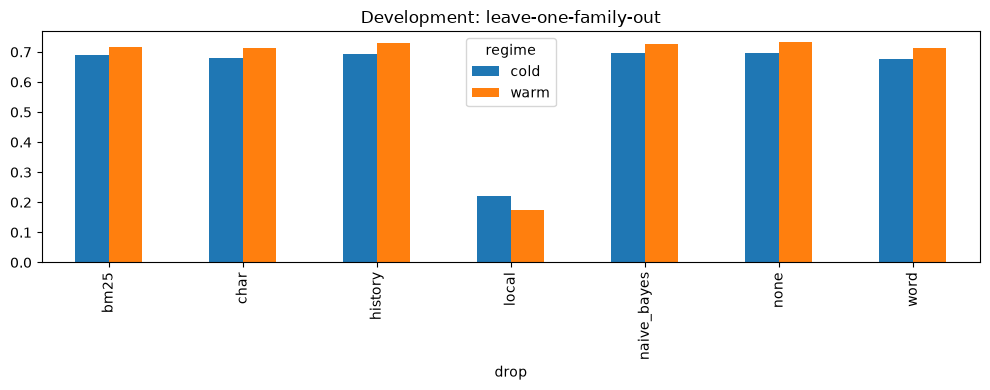

In [18]:
hy_ablations = []
for hy_drop in ['none', 'local', 'history', 'char', 'word', 'bm25', 'naive_bayes']:
    hy_ab_weights = {
        s: w for s, w in hy_weights.items() if hy_drop == 'none' or hy_drop not in s
    }
    hy_pred = predictions_from_frame(
        rrf(hy_candidates, hy_ab_weights, constant=30, top_k=100), hy_items, k=100
    )
    hy_result = recall_table(hy_pred, hy_truth).merge(
        hy_dev[['query_id', 'regime']], on='query_id'
    )
    for hy_regime, hy_part in hy_result.groupby('regime'):
        hy_ablations.append(
            {
                'drop': hy_drop,
                'regime': hy_regime,
                'recall@50': hy_part['recall@50'].mean(),
            }
        )
hy_ablations = pd.DataFrame(hy_ablations)
hy_ablations.to_csv(hy_out / 'validation/hybrid_ablations.csv', index=False)
display(hy_ablations)
hy_ablations.pivot(index='drop', columns='regime', values='recall@50').plot.bar(
    figsize=(10, 4), title='Development: leave-one-family-out'
)
plt.tight_layout()
plt.savefig(hy_out / 'figures/hybrid_ablations.png', dpi=150)
plt.show()


## Итог сравнения

Локальный BM25 дает 0.61111 на cold и 0.65876 на warm. RRF поднимает их до
0.69681 и 0.73190; взвешенное среднее -- 0.70996. Без локальных каналов качество
сильно падает. При этом глобальный поиск сохраняю: часть выбранных объявлений находится
в другой локации, поэтому жесткое отсечение здесь не подходит.